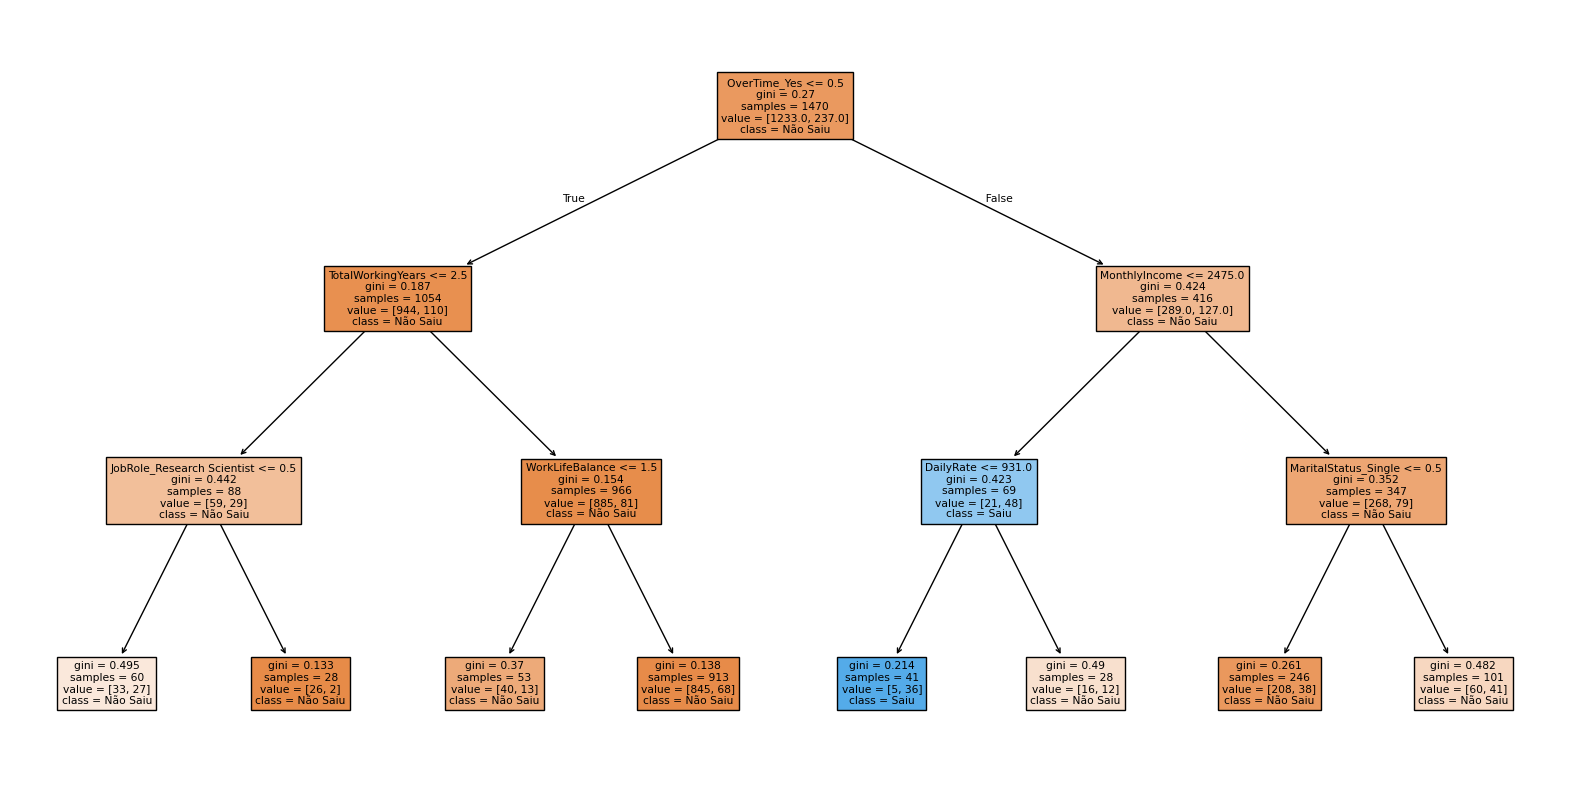

|--- OverTime_Yes <= 0.50
|   |--- TotalWorkingYears <= 2.50
|   |   |--- JobRole_Research Scientist <= 0.50
|   |   |   |--- class: 0
|   |   |--- JobRole_Research Scientist >  0.50
|   |   |   |--- class: 0
|   |--- TotalWorkingYears >  2.50
|   |   |--- WorkLifeBalance <= 1.50
|   |   |   |--- class: 0
|   |   |--- WorkLifeBalance >  1.50
|   |   |   |--- class: 0
|--- OverTime_Yes >  0.50
|   |--- MonthlyIncome <= 2475.00
|   |   |--- DailyRate <= 931.00
|   |   |   |--- class: 1
|   |   |--- DailyRate >  931.00
|   |   |   |--- class: 0
|   |--- MonthlyIncome >  2475.00
|   |   |--- MaritalStatus_Single <= 0.50
|   |   |   |--- class: 0
|   |   |--- MaritalStatus_Single >  0.50
|   |   |   |--- class: 0



In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Pre Processamento de dados

df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df_final = pd.get_dummies(df, drop_first=True)

# Separar Features (X) e Target (y)
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

# --- CRIAÇÃO DOS MODELOS ---

# Exemplo com CART (Gini)
model_cart = DecisionTreeClassifier(criterion='gini', max_depth=3)
model_cart.fit(X, y)

# Visualização da Árvore
plt.figure(figsize=(20,10))
plot_tree(model_cart, feature_names=X.columns, class_names=['Não Saiu', 'Saiu'], filled=True)
plt.show()

# Base de Regras
print(export_text(model_cart, feature_names=list(X.columns)))